In [2]:
import pandas as pd

jobs = pd.read_csv('../data/job_postings.csv')
skills = pd.read_csv('../data/job_skills.csv')

print(jobs.shape)
print(skills.shape)

(15886, 27)
(27899, 2)


In [3]:
print(jobs.columns)
print(skills.columns)


Index(['job_id', 'company_id', 'title', 'description', 'max_salary',
       'med_salary', 'min_salary', 'pay_period', 'formatted_work_type',
       'location', 'applies', 'original_listed_time', 'remote_allowed',
       'views', 'job_posting_url', 'application_url', 'application_type',
       'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc',
       'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type'],
      dtype='object')
Index(['job_id', 'skill_abr'], dtype='object')


In [4]:
df = pd.merge(jobs, skills, on='job_id')

print(df.shape)
df.head()

(26967, 28)


,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,...,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,skill_abr
0,85008768,NaN,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.0,NaN,45760.0,YEARLY,Full-time,"Chico, CA",...,NaN,NaN,NaN,1.690000e+12,NaN,1,FULL_TIME,USD,BASE_SALARY,SALE
1,85008768,NaN,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.0,NaN,45760.0,YEARLY,Full-time,"Chico, CA",...,NaN,NaN,NaN,1.690000e+12,NaN,1,FULL_TIME,USD,BASE_SALARY,BD
2,133114754,77766802.0,Sales Manager,Are you a dynamic and creative marketing profe...,NaN,NaN,NaN,NaN,Full-time,"Santa Clarita, CA",...,NaN,NaN,NaN,1.690000e+12,NaN,0,FULL_TIME,NaN,NaN,SALE
3,133114754,77766802.0,Sales Manager,Are you a dynamic and creative marketing profe...,NaN,NaN,NaN,NaN,Full-time,"Santa Clarita, CA",...,NaN,NaN,NaN,1.690000e+12,NaN,0,FULL_TIME,NaN,NaN,BD
4,133196985,1089558.0,Model Risk Auditor,Join Us as a Model Risk Auditor – Showcase You...,NaN,NaN,NaN,NaN,Contract,"New York, NY",...,NaN,NaN,NaN,1.690000e+12,NaN,0,CONTRACT,NaN,NaN,ACCT


In [5]:
df = df[df['title'].str.contains('Data', case=False, na=False)]

print(df.shape)

(595, 28)


In [6]:
print(df.columns)

Index(['job_id', 'company_id', 'title', 'description', 'max_salary',
       'med_salary', 'min_salary', 'pay_period', 'formatted_work_type',
       'location', 'applies', 'original_listed_time', 'remote_allowed',
       'views', 'job_posting_url', 'application_url', 'application_type',
       'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc',
       'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'skill_abr'],
      dtype='object')


In [7]:
df = df[df['title'].str.contains('Data', case=False, na=False)].copy()

In [8]:
df.loc[:, 'skill_abr'] = df['skill_abr'].str.upper()

top_skills = df['skill_abr'].value_counts().head(15)
print(top_skills)

IT      243
ENG      70
ANLS     33
CNSL     25
STRA     21
OTHR     20
RSCH     19
MGMT     18
MNFC     15
ADM      15
PRJM     14
GENB     13
FIN      11
CUST      9
SALE      9
Name: skill_abr, dtype: int64


In [9]:
skill_mapping = {
    'IT': 'Information Technology',
    'ENG': 'Engineering',
    'ANLS': 'Analytics',
    'CNSL': 'Consulting',
    'STRA': 'Strategy',
    'MGMT': 'Management',
    'RSCH': 'Research',
    'PRJM': 'Project Management',
    'FIN': 'Finance',
    'SALE': 'Sales',
    'CUST': 'Customer Service'
}

df['skill_name'] = df['skill_abr'].map(skill_mapping).fillna(df['skill_abr'])

In [10]:
top_skills = df['skill_name'].value_counts().head(10)
print(top_skills)

Information Technology    243
Engineering                70
Analytics                  33
Consulting                 25
Strategy                   21
OTHR                       20
Research                   19
Management                 18
MNFC                       15
ADM                        15
Name: skill_name, dtype: int64


In [11]:
df['title'].value_counts().head(10)

Senior Data Scientist                       35
Data Scientist                              20
Data Engineer                               15
Senior Data Engineer                        15
Data Center Logistics Associate L1          12
Data Analyst                                12
Staff Data Engineer and Team Lead           12
Product Analyst Manager II, Data Science    12
CLASS Data Assessor                         10
Data Collection  -  Supplementary Income     9
Name: title, dtype: int64

In [12]:
df['location'].value_counts().head(10)

United States        81
Atlanta, GA          21
Seattle, WA          14
Chicago, IL          14
Charlotte, NC        13
Dallas, TX           12
New York, NY         11
Austin, TX           11
Boston, MA           10
Mountain View, CA     9
Name: location, dtype: int64

In [13]:
df[['min_salary','max_salary']].dropna().describe()

,min_salary,max_salary
count,240.000000,240.000000
mean,87811.609833,124468.663875
std,63029.193477,91334.809984
min,15.000000,17.000000
25%,45898.500000,53750.000000
50%,90000.000000,135000.000000
75%,145250.000000,181250.000000
max,266815.000000,364100.000000


In [14]:
df['title'].value_counts().head(10)
df['location'].value_counts().head(10)
print(top_skills)

Information Technology    243
Engineering                70
Analytics                  33
Consulting                 25
Strategy                   21
OTHR                       20
Research                   19
Management                 18
MNFC                       15
ADM                        15
Name: skill_name, dtype: int64


In [15]:
df['title'].value_counts().head(10)
df['location'].value_counts().head(10)

United States        81
Atlanta, GA          21
Seattle, WA          14
Chicago, IL          14
Charlotte, NC        13
Dallas, TX           12
New York, NY         11
Austin, TX           11
Boston, MA           10
Mountain View, CA     9
Name: location, dtype: int64

In [16]:
df.to_csv('../data/processed_jobs.csv', index=False)

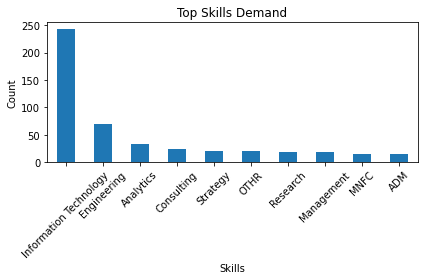

In [17]:
import matplotlib.pyplot as plt

# Top Skills
top_skills = df['skill_name'].value_counts().head(10)

plt.figure()
top_skills.plot(kind='bar')
plt.title('Top Skills Demand')
plt.xlabel('Skills')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

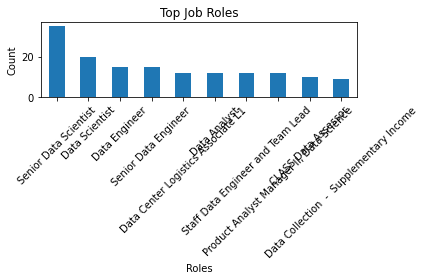

In [18]:
top_roles = df['title'].value_counts().head(10)

plt.figure()
top_roles.plot(kind='bar')
plt.title('Top Job Roles')
plt.xlabel('Roles')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

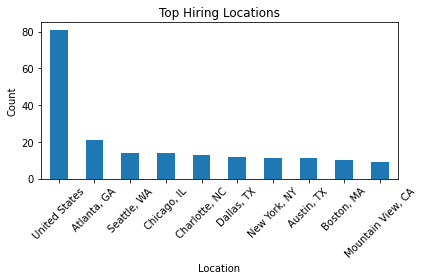

In [19]:
top_locations = df['location'].value_counts().head(10)

plt.figure()
top_locations.plot(kind='bar')
plt.title('Top Hiring Locations')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

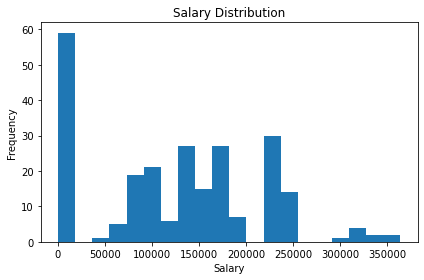

In [20]:
plt.figure()
df['max_salary'].dropna().plot(kind='hist', bins=20)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [22]:
df.head(1000).to_csv('../data/processed_jobs_small.csv', index=False)